<a href="https://colab.research.google.com/github/DineshGujjeti/spam-email-classifier-ml/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Install Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

##Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

data = pd.read_csv(url, sep='\t', names=['label', 'message'])

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


##Convert Labels

In [3]:
data['label'] = data['label'].map({'ham':0, 'spam':1})

##Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data['message'],
    data['label'],
    test_size=0.2,
    random_state=42
)

##TF-IDF Vectorization

In [5]:
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

##Train Model

In [6]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

MultinomialNB()

##Make Predictions

In [7]:
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.97847533632287


##Confusion Matrix

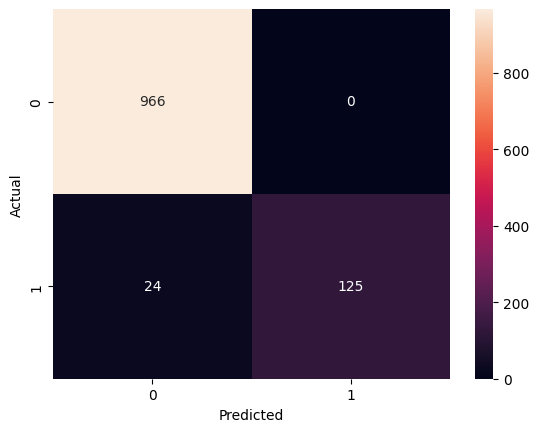

In [8]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Test Custom Message

In [14]:
msg = ["Hey, are we meeting tomorrow?"]

msg_vec = vectorizer.transform(msg)

prediction = model.predict(msg_vec)

print("Spam" if prediction[0]==1 else "Not Spam")

Not Spam


In [11]:
msg = ["Win a free iPhone now! Click this link"]

msg_vec = vectorizer.transform(msg)

prediction = model.predict(msg_vec)

print("Spam" if prediction[0]==1 else "Not Spam")

Spam


In [13]:
msg = ["URGENT! Claim your prize money now"]

msg_vec = vectorizer.transform(msg)

prediction = model.predict(msg_vec)

print("Spam" if prediction[0]==1 else "Not Spam")

Spam


##Model Performance

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

